Saving mldl 3.zip to mldl 3 (2).zip
===== Dataset Preview =====
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  


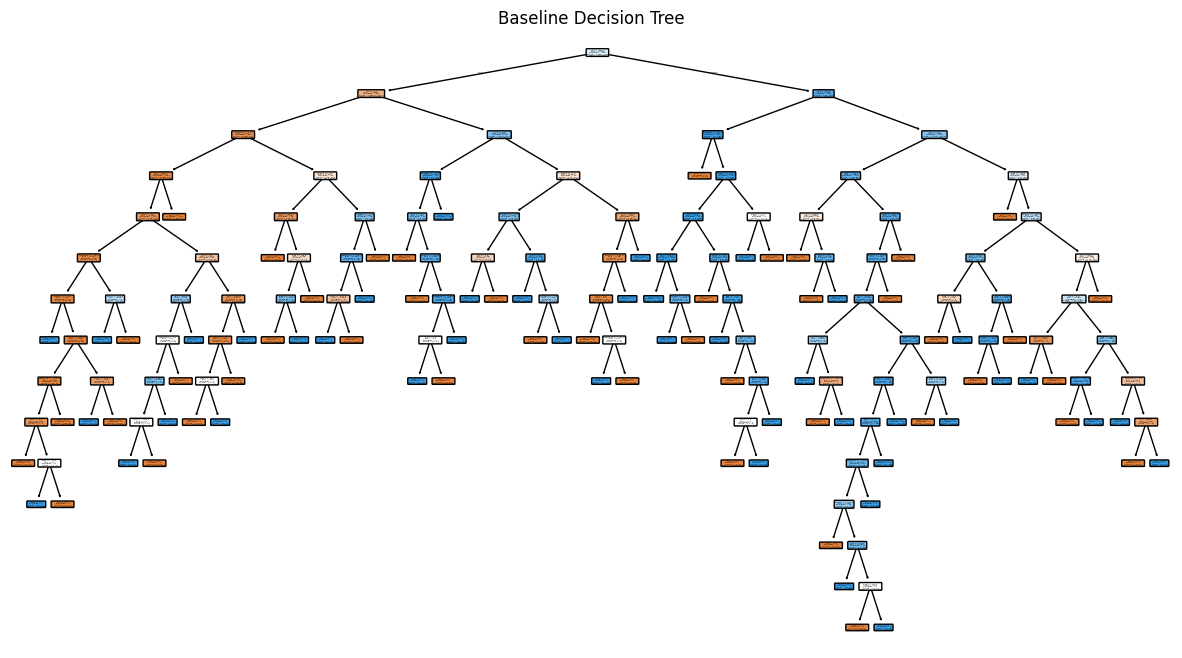

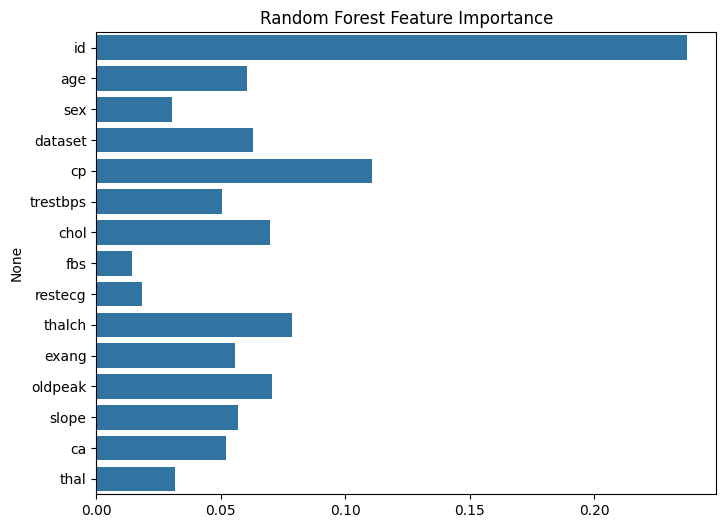

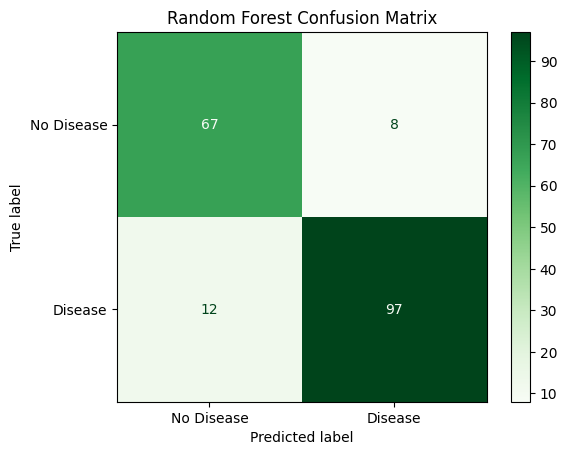


===== Tuned Metrics =====
                   Model  Accuracy (%)  Precision (%)  Recall (%)  \
0  Decision Tree (Tuned)         85.87          88.79       87.16   
1  Random Forest (Tuned)         89.67          91.67       90.83   

   F1-Score (%)  
0         87.96  
1         91.24  

Best DT Params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}
Best RF Params: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 50}


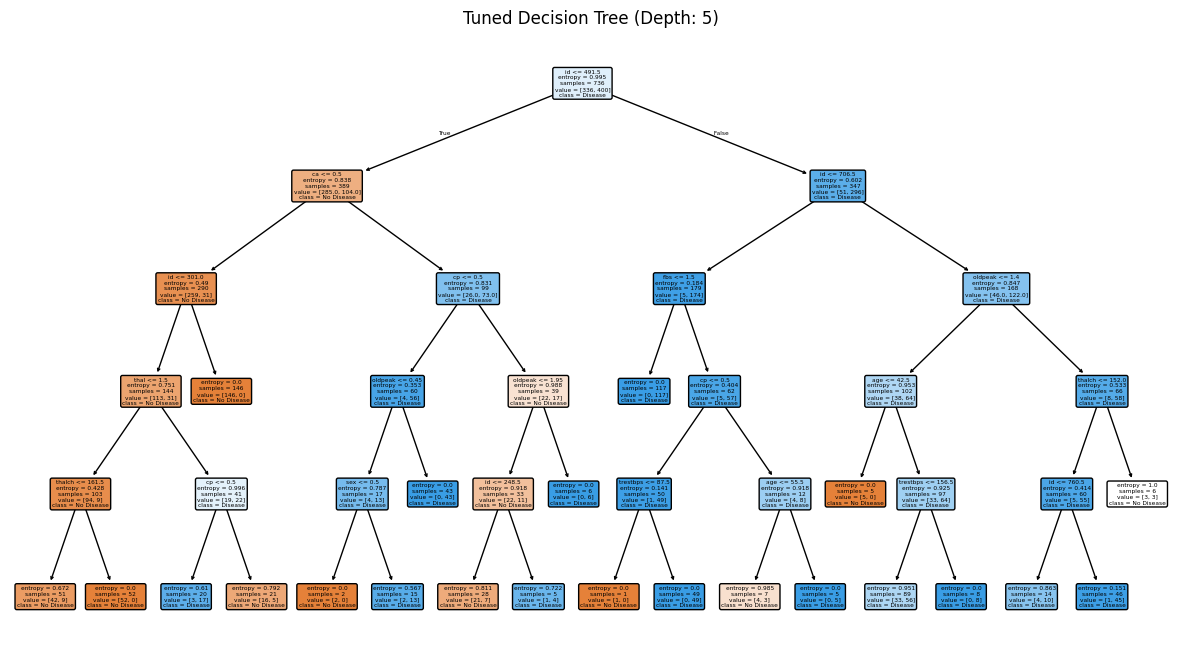

In [ ]:
# =====================================================
# Decision Tree & Random Forest Classification
# Dataset: Heart Disease (Different from PDF)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# ===============================
# Upload Dataset (Colab Safe)
# ===============================

from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("===== Dataset Preview =====")
print(df.head())

# ===============================
# Encode Categorical Features
# ===============================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

# ===============================
# Prepare Data
# ===============================

X = df.drop("num", axis=1)
y = df["num"]

# Convert to Binary
y = y.apply(lambda x: 1 if x > 0 else 0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# Baseline Models
# ===============================

dt_base = DecisionTreeClassifier(random_state=42)
rf_base = RandomForestClassifier(random_state=42)

dt_base.fit(X_train, y_train)
rf_base.fit(X_train, y_train)

# ===============================
# Evaluation Function
# ===============================

def get_metrics(model, name):
    preds = model.predict(X_test)
    return {
        "Model": name,
        "Accuracy (%)": round(accuracy_score(y_test, preds)*100,2),
        "Precision (%)": round(precision_score(y_test, preds)*100,2),
        "Recall (%)": round(recall_score(y_test, preds)*100,2),
        "F1-Score (%)": round(f1_score(y_test, preds)*100,2)
    }

metrics_base = [
    get_metrics(dt_base, "Decision Tree (Baseline)"),
    get_metrics(rf_base, "Random Forest (Baseline)")
]

print("\n===== Baseline Metrics =====")
print(pd.DataFrame(metrics_base))

# ===============================
# Baseline Visualizations
# ===============================

# Decision Tree Diagram
plt.figure(figsize=(15,8))
plot_tree(dt_base, feature_names=X.columns,
          class_names=["No Disease","Disease"],
          filled=True, rounded=True)
plt.title("Baseline Decision Tree")
plt.show()

# Random Forest Feature Importance
plt.figure(figsize=(8,6))
importances = rf_base.feature_importances_
sns.barplot(x=importances, y=X.columns)
plt.title("Random Forest Feature Importance")
plt.show()

# Confusion Matrix (Random Forest)
ConfusionMatrixDisplay.from_estimator(
    rf_base, X_test, y_test,
    display_labels=["No Disease","Disease"],
    cmap="Greens"
)
plt.title("Random Forest Confusion Matrix")
plt.show()

# ===============================
# Hyperparameter Tuning
# ===============================

param_grid_dt = {
    "max_depth":[3,5,10],
    "min_samples_split":[2,5,10],
    "criterion":["gini","entropy"]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5
)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_

param_grid_rf = {
    "n_estimators":[50,100],
    "max_depth":[5,10,None],
    "min_samples_leaf":[1,2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5
)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

# ===============================
# Tuned Metrics
# ===============================

metrics_tuned = [
    get_metrics(best_dt, "Decision Tree (Tuned)"),
    get_metrics(best_rf, "Random Forest (Tuned)")
]

print("\n===== Tuned Metrics =====")
print(pd.DataFrame(metrics_tuned))

print("\nBest DT Params:", grid_dt.best_params_)
print("Best RF Params:", grid_rf.best_params_)

# ===============================
# Tuned Tree Visualization
# ===============================

plt.figure(figsize=(15,8))
plot_tree(best_dt, feature_names=X.columns,
          class_names=["No Disease","Disease"],
          filled=True, rounded=True)
plt.title(f"Tuned Decision Tree (Depth: {best_dt.get_depth()})")
plt.show()